# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Leann Vo

**Date:** 9/7/2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Question 1**


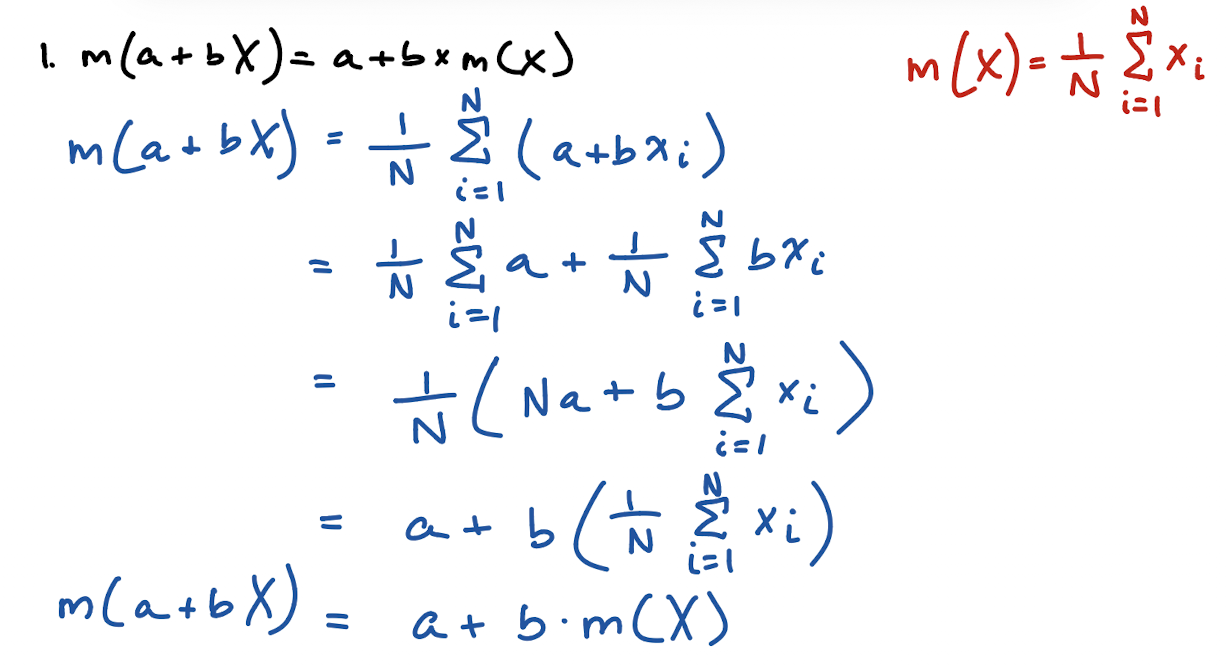

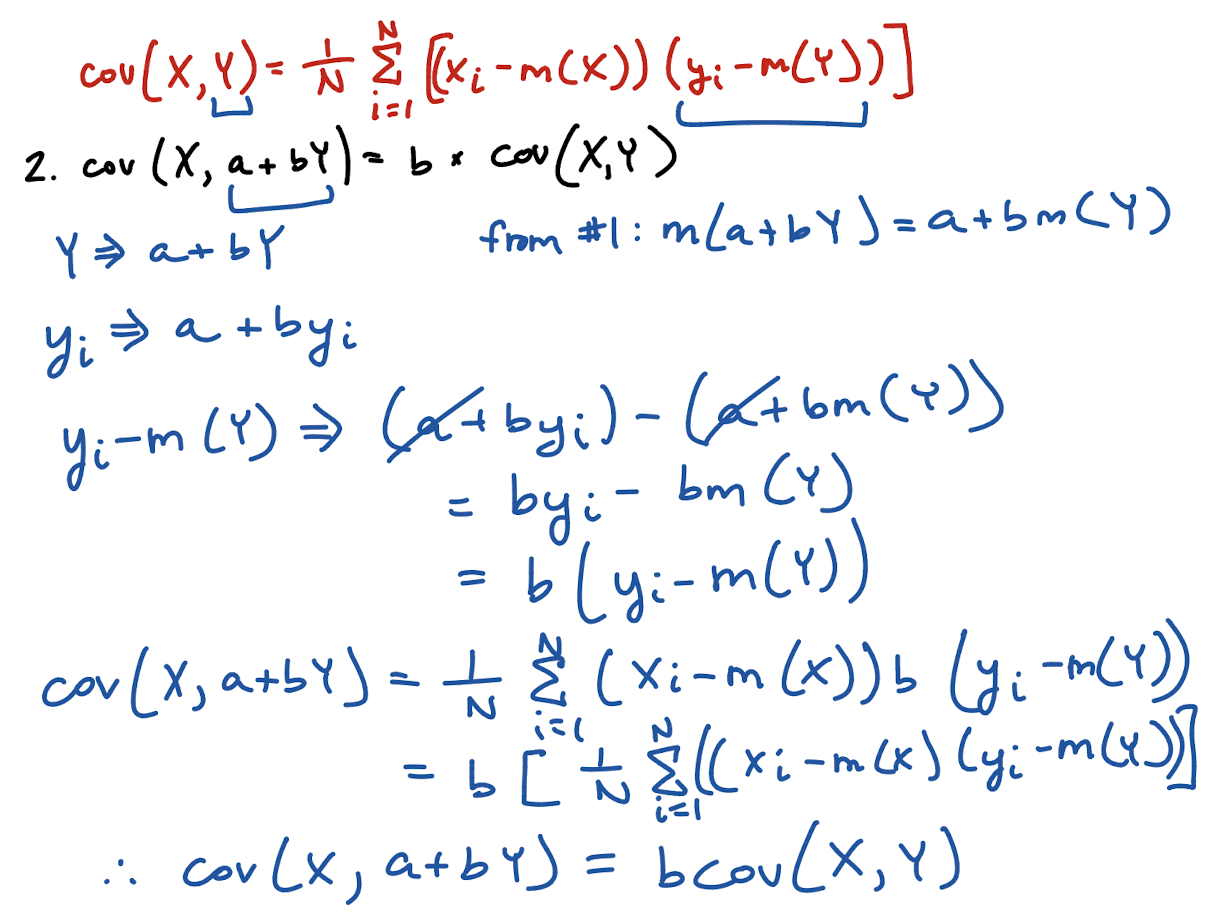

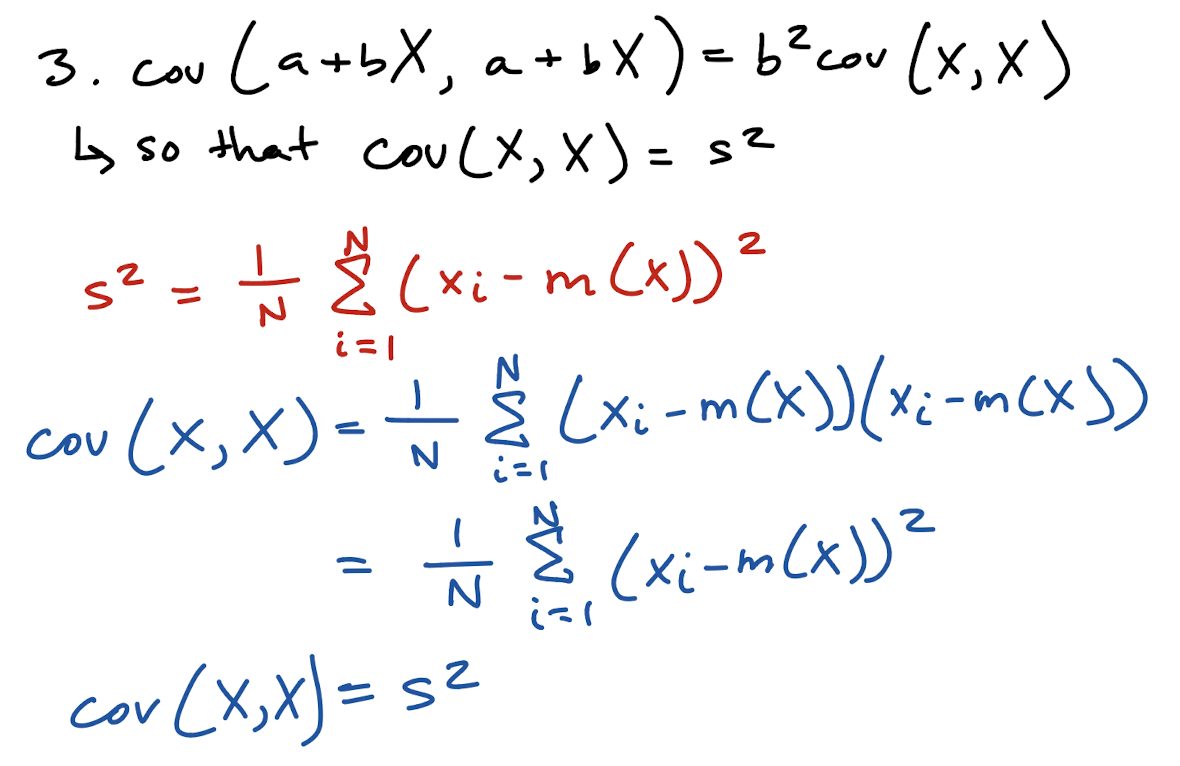

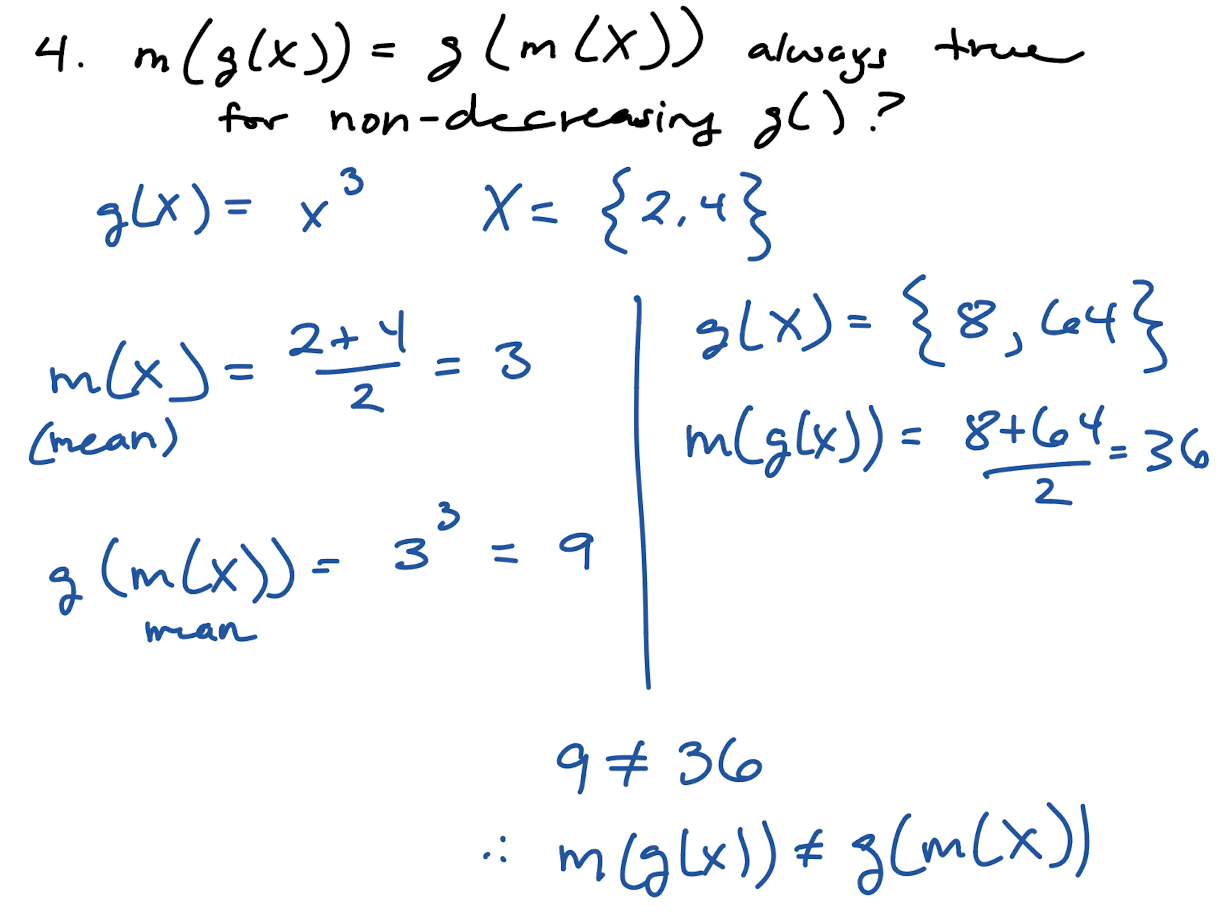

**Question 2**

In [2]:
df = pd.read_csv('./ForeignGifts_edu.csv')
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


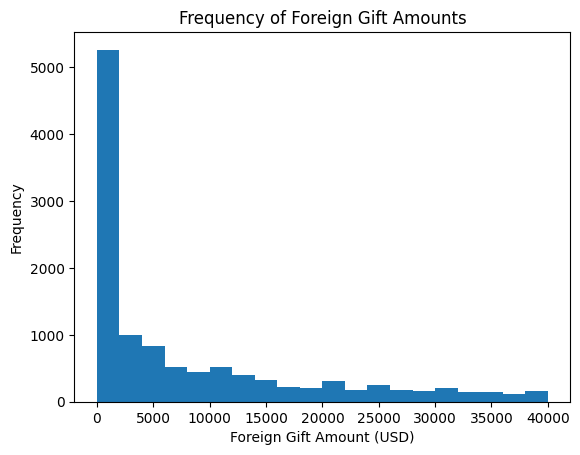

In [3]:
# 2. Foreign Gift Amount Histogram
df['Foreign Gift Amount'].hist(bins=20,grid=False, range=(0, 40000))
plt.xlabel('Foreign Gift Amount (USD)')
plt.ylabel('Frequency')
plt.title('Frequency of Foreign Gift Amounts')
plt.show()

In [4]:
df['Foreign Gift Amount'].describe()

,Foreign Gift Amount
count,2.822100e+04
mean,5.882327e+05
std,3.222011e+06
min,-5.377700e+05
25%,5.700000e+03
50%,9.461500e+04
75%,3.761420e+05
max,1.000000e+08


The histogram above displays the frequency of foreign gift amounts received by American universities. The foreign gift amount is measured in US dollars. The distribution for the frequency of foreign gift amounts is strongly skewed to the right. The median gift is about 94,615 dollars and the mean is 588,233 dollars. The maximum gift was 100 million dollars and the minimum was oddly -537,770 dollars.


In [5]:
# 3. Gift Type Frequency Table

print(df['Gift Type'].value_counts())
print(df['Gift Type'].value_counts(normalize=True)) # normalize=True changes counts into proportions

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


Create a kernel density plot of the log of Foreign Gift Amount, and then a kernel density plot of the log of Foreign Gift Amount conditional on gift type. Do you notice any patterns?

/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


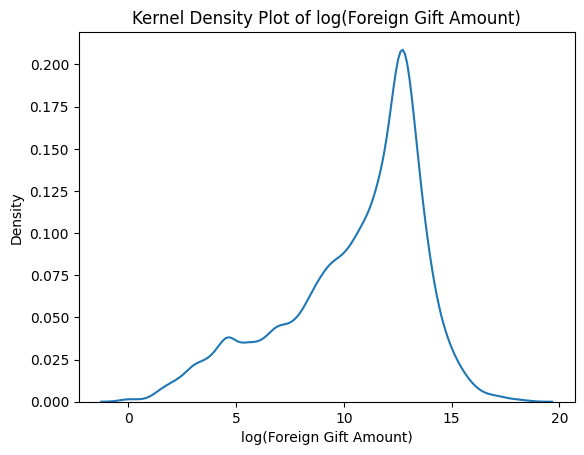

In [6]:
# 4. Kernel Density Plot for log(Foreign Gift Amount)
df['log_foreign_gift_amount'] = np.log(df['Foreign Gift Amount'])
sns.kdeplot(df['log_foreign_gift_amount'])

plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.title('Kernel Density Plot of log(Foreign Gift Amount)')
plt.show()

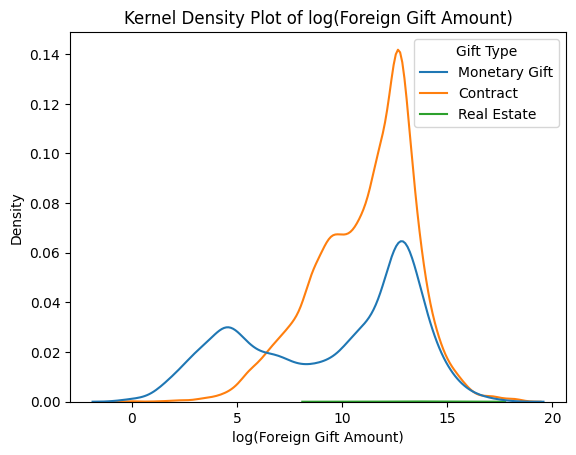

In [7]:
# 4-cont. Kernel Density Plot for log(Foreign Gift Amount) conditional on Gift Type
sns.kdeplot(data=df, x='log_foreign_gift_amount', hue='Gift Type')
plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.title('Kernel Density Plot of log(Foreign Gift Amount)')
plt.show()

Contracts and monetary gifts are very concentrated at higher log gift amounts. The monetary gifts also show a second peak at a lower log value. The real estate curve appears to be almost flat. I'm assuming this is because there are only 11 real estate gifts so there isn't enough data to reveal any pattern.

In [8]:
# 5. Top 15 Countries with Most Gifts
country_counts = df.groupby('Country of Giftor').size()
# groups all rows from the same country together and then counts how many gifts/rows are in each country
country_counts = country_counts.sort_values(ascending=False) # False puts largest counts first
print(country_counts.head(15))

# Top 15 Countries by Amount Given
country_amounts = df.groupby('Country of Giftor')['Foreign Gift Amount'].sum()
country_amounts = country_amounts.sort_values(ascending=False)
print(country_amounts.head(15))

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


England had recieved the greatest number of foreign gifts at 3,655 gifts. Qatar gifted the most money overall at approximately 2.71 billion.

In [9]:
# 6. Giftors who have donated the most money
giftor_amounts = df.groupby('Giftor Name')['Foreign Gift Amount'].sum()
giftor_amounts = giftor_amounts.sort_values(ascending=False)
print(giftor_amounts.head(15))

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Qatar National Research Fund             79021705
Government of Saudi Arabia               75192434
Contracting Party                        69996984
CMKL University                          67700000
Royal Embassy of Saudi Arabia            67062486
Name: Foreign Gift Amount, dtype: int64


The Qatar Foundation donated the most money in total at about 1.17 billion dollars. Two additional Qatar-related Foundation giftors also donated alot of money.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [10]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]